In [402]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [403]:
df = pd.DataFrame()

In [404]:
df['X1']=[1,2,3,4,5,6,7,8,9,9]
df['X2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]

In [405]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,7,5,0
7,8,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

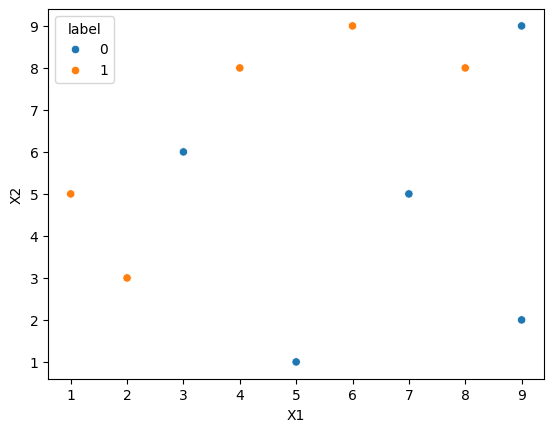

In [406]:
import seaborn as sns

sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

In [407]:
df['weights']= 1/df.shape[0]

In [408]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,7,5,0,0.1
7,8,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [409]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

dt1=DecisionTreeClassifier(max_depth=1)

In [410]:
X=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [411]:
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

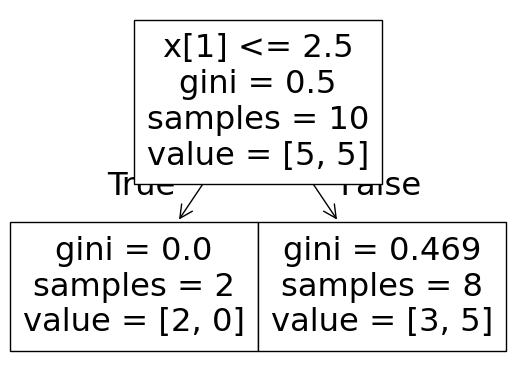

In [412]:
plot_tree(dt1)

<Axes: >

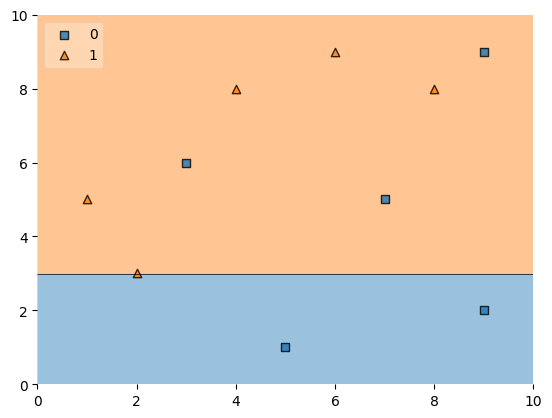

In [413]:
plot_decision_regions(X,y,clf=dt1,legend=2)

In [414]:
df['y_pred']=dt1.predict(X)

In [415]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,7,5,0,0.1,1
7,8,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [416]:
def calculate_model_weight(error):
  return 0.5 * np.log((1-error)/(error))

In [417]:
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [418]:
def update_row_weights(row,alpha=0.42364893019360184):
  if row['label']==row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [419]:
df['updated_weights']=df.apply(update_row_weights,axis=1)

In [420]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065465
1,2,3,1,0.1,1,0.065465
2,3,6,0,0.1,1,0.152753
3,4,8,1,0.1,1,0.065465
4,5,1,0,0.1,0,0.065465
5,6,9,1,0.1,1,0.065465
6,7,5,0,0.1,1,0.152753
7,8,8,1,0.1,1,0.065465
8,9,9,0,0.1,1,0.152753
9,9,2,0,0.1,0,0.065465


In [421]:
df['normalized_weights']=df['updated_weights']/(df['updated_weights'].sum())

In [422]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065465,0.071429
1,2,3,1,0.1,1,0.065465,0.071429
2,3,6,0,0.1,1,0.152753,0.166667
3,4,8,1,0.1,1,0.065465,0.071429
4,5,1,0,0.1,0,0.065465,0.071429
5,6,9,1,0.1,1,0.065465,0.071429
6,7,5,0,0.1,1,0.152753,0.166667
7,8,8,1,0.1,1,0.065465,0.071429
8,9,9,0,0.1,1,0.152753,0.166667
9,9,2,0,0.1,0,0.065465,0.071429


In [423]:
df['normalized_weights'].sum()

np.float64(0.9999999999999999)

In [424]:
df['cumsum_upper']=np.cumsum(df['normalized_weights'])

In [425]:
df['cumsum_lower']=df['cumsum_upper'] - df['normalized_weights']

In [426]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065465,0.071429,0.071429,0.000000
1,2,3,1,0.1,1,0.065465,0.071429,0.142857,0.071429
2,3,6,0,0.1,1,0.152753,0.166667,0.309524,0.142857
3,4,8,1,0.1,1,0.065465,0.071429,0.380952,0.309524
4,5,1,0,0.1,0,0.065465,0.071429,0.452381,0.380952
5,6,9,1,0.1,1,0.065465,0.071429,0.523810,0.452381
6,7,5,0,0.1,1,0.152753,0.166667,0.690476,0.523810
7,8,8,1,0.1,1,0.065465,0.071429,0.761905,0.690476
8,9,9,0,0.1,1,0.152753,0.166667,0.928571,0.761905
9,9,2,0,0.1,0,0.065465,0.071429,1.000000,0.928571


In [427]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices


In [428]:
index_values = create_new_dataset(df)

In [429]:
index_values

[1, 8, 9, 1, 1, 6, 1, 3, 7, 3]

In [430]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [431]:
second_df

,X1,X2,label,weights
1,2,3,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
1,2,3,1,0.1
1,2,3,1,0.1
6,7,5,0,0.1
1,2,3,1,0.1
3,4,8,1,0.1
7,8,8,1,0.1
3,4,8,1,0.1


In [432]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [433]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [434]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 5.5\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.625, 0.5, '  False')]

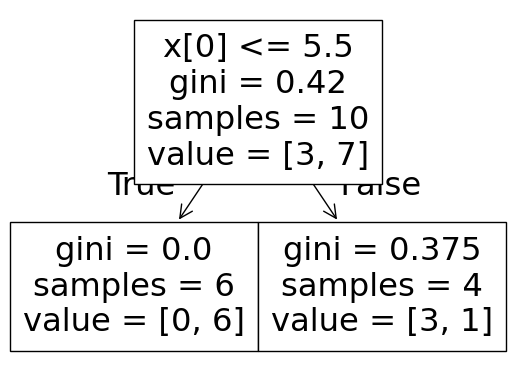

In [435]:
plot_tree(dt2)

<Axes: >

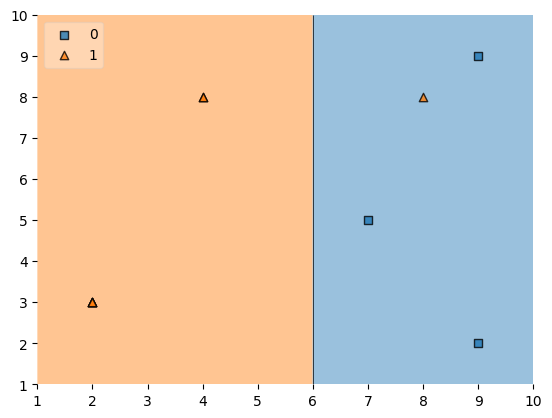

In [436]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [437]:
second_df['y_pred'] = dt2.predict(X)

In [438]:
second_df

,X1,X2,label,weights,y_pred
1,2,3,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0
1,2,3,1,0.1,1
1,2,3,1,0.1,1
6,7,5,0,0.1,0
1,2,3,1,0.1,1
3,4,8,1,0.1,1
7,8,8,1,0.1,0
3,4,8,1,0.1,1


In [439]:
alpha2 = calculate_model_weight(0.1)

In [440]:
alpha2

np.float64(1.0986122886681098)

In [441]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [442]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)


In [443]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
1,2,3,1,0.1,1,0.033622
8,9,9,0,0.1,0,0.033622
9,9,2,0,0.1,0,0.033622
1,2,3,1,0.1,1,0.033622
1,2,3,1,0.1,1,0.033622
6,7,5,0,0.1,0,0.033622
1,2,3,1,0.1,1,0.033622
3,4,8,1,0.1,1,0.033622
7,8,8,1,0.1,0,0.297427
3,4,8,1,0.1,1,0.033622


In [444]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()


In [445]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
1,2,3,1,0.1,1,0.033622,0.056034
8,9,9,0,0.1,0,0.033622,0.056034
9,9,2,0,0.1,0,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
6,7,5,0,0.1,0,0.033622,0.056034
1,2,3,1,0.1,1,0.033622,0.056034
3,4,8,1,0.1,1,0.033622,0.056034
7,8,8,1,0.1,0,0.297427,0.495694
3,4,8,1,0.1,1,0.033622,0.056034


In [446]:
second_df['nomalized_weights'].sum()


np.float64(1.0)

In [447]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])


In [448]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']


In [449]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]


,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
1,2,3,1,0.1,1,0.056034,0.000000,0.056034
8,9,9,0,0.1,0,0.056034,0.056034,0.112068
9,9,2,0,0.1,0,0.056034,0.112068,0.168102
1,2,3,1,0.1,1,0.056034,0.168102,0.224136
1,2,3,1,0.1,1,0.056034,0.224136,0.280170
6,7,5,0,0.1,0,0.056034,0.280170,0.336204
1,2,3,1,0.1,1,0.056034,0.336204,0.392238
3,4,8,1,0.1,1,0.056034,0.392238,0.448272
7,8,8,1,0.1,0,0.495694,0.448272,0.943966
3,4,8,1,0.1,1,0.056034,0.943966,1.000000


In [450]:
index_values = create_new_dataset(second_df)

In [451]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [452]:
third_df

,X1,X2,label,weights
3,4,8,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
3,4,8,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1


In [453]:
dt3 = DecisionTreeClassifier(max_depth=1)


In [454]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [455]:
dt3.fit(X,y)


DecisionTreeClassifier(max_depth=1)

<Axes: >

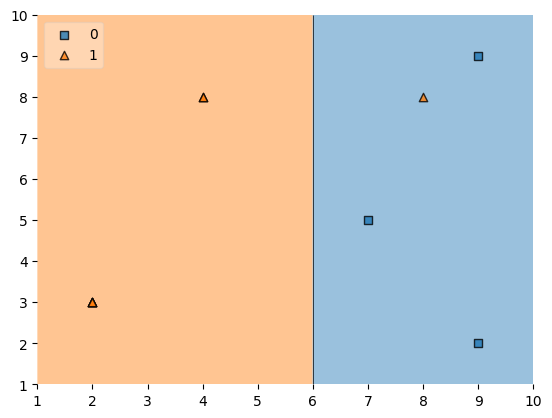

In [456]:
plot_decision_regions(X, y, clf=dt3, legend=2)


In [457]:
third_df['y_pred'] = dt3.predict(X)


In [458]:
third_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,1
3,4,8,1,0.1,0
1,2,3,1,0.1,0
8,9,9,0,0.1,1
3,4,8,1,0.1,1
3,4,8,1,0.1,0
3,4,8,1,0.1,1
3,4,8,1,0.1,1
1,2,3,1,0.1,0
8,9,9,0,0.1,1


In [459]:
alpha3 = calculate_model_weight(0.7)
alpha3


np.float64(-0.4236489301936017)

In [460]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


In [461]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [462]:
dt2.predict(query)


array([1])

In [463]:
dt3.predict(query)


array([1])

In [465]:
alpha1*(1) + alpha2*(1) + alpha3*(1)

np.float64(1.09861228866811)

In [466]:
np.sign(1.09)


np.float64(1.0)

In [467]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)


array([1])

In [468]:
dt2.predict(query)

array([0])

In [469]:
dt3.predict(query)


array([0])

In [470]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)


np.float64(-0.2513144282809062)

In [471]:
np.sign(-0.2513144282809062)

np.float64(-1.0)